In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

In [2]:
df = pd.read_csv("test.csv")
df.head()

,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


In [3]:
df["text"] = df["Title"] + " " + df["Description"]
df.head()

,Class Index,Title,Description,text
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...,Fears for T N pension after talks Unions repre...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o...",The Race is On: Second Private Team Sets Launc...
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...,Ky. Company Wins Grant to Study Peptides (AP) ...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...,Prediction Unit Helps Forecast Wildfires (AP) ...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...,Calif. Aims to Limit Farm-Related Smog (AP) AP...


In [4]:
X = df["text"]
y = df["Class Index"] - 1

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)


In [7]:
max_length = 100
X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

In [8]:
model = Sequential()

model.add(Embedding(input_dim=10000, output_dim=64))

model.add(SimpleRNN(64))

model.add(Dense(4, activation="softmax"))

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.3039 - loss: 1.3657 - val_accuracy: 0.4071 - val_loss: 1.2572
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.7621 - loss: 0.7683 - val_accuracy: 0.5362 - val_loss: 0.9385
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9661 - loss: 0.2073 - val_accuracy: 0.5461 - val_loss: 1.0175
Epoch 4/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9998 - loss: 0.0261 - val_accuracy: 0.5535 - val_loss: 1.1802
Epoch 5/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 1.0000 - loss: 0.0079 - val_accuracy: 0.5650 - val_loss: 1.2002


In [10]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5658 - loss: 1.1883
Test Accuracy: 0.5657894611358643


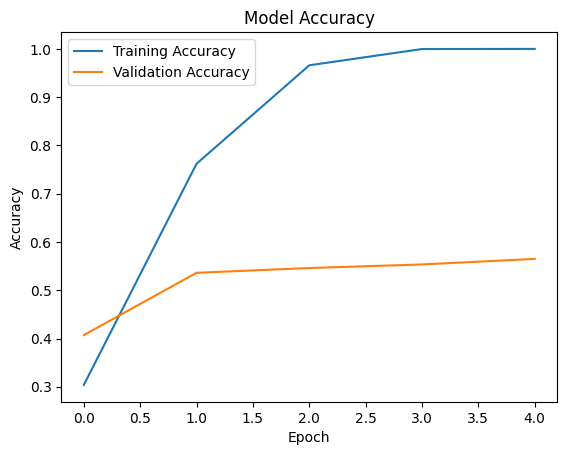

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()

plt.show()

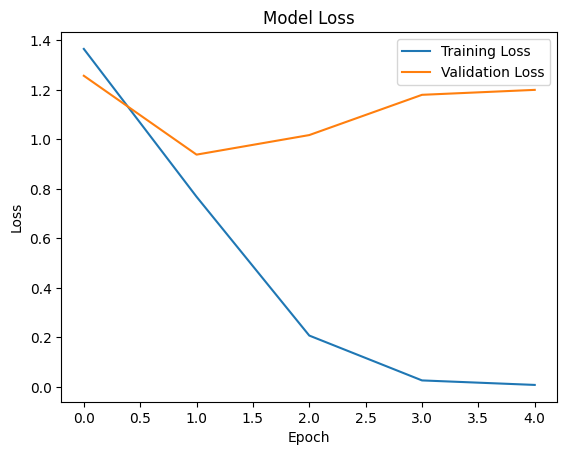

In [12]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()

plt.show()

In [13]:
categories = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Science/Technology"
}

text = input("Enter News: ")

seq = tokenizer.texts_to_sequences([text])

pad = pad_sequences(seq, maxlen=max_length)

prediction = model.predict(pad)

index = np.argmax(prediction)

print("Predicted Category:", categories[index])


Enter News:  Apple launches a new AI-powered smartphone with advanced features.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
Predicted Category: World
